In [ ]:
# !pip install pyLDAvis
# !pip install gensim

import pandas as pd
import nltk; nltk.download('stopwords')
from nltk.corpus import stopwords

# Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
from gensim.models import LdaModel
from gensim.models import CoherenceModel

import pyLDAvis
import matplotlib.pyplot as plt
%matplotlib inline

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
data = pd.read_csv('highconf_label_data.csv')

cat = 2.0

data = data[data['label'] == cat].reset_index(drop=True)
data = data.dropna(subset=['preprocessed'])

data['tokenized'] = [doc.split() for doc in data['preprocessed']]

preprocessed = data['tokenized'].to_list()

In [ ]:
bigram = gensim.models.Phrases(preprocessed, min_count=5, threshold=100)
trigram = gensim.models.Phrases(bigram[preprocessed], threshold=100)

bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

In [ ]:
import string
import re

stop_words = stopwords.words('english')
stop_words.append('like')
stop_words = [re.sub(f"[{re.escape(string.punctuation)}]", "", word) for word in stop_words]

def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]

In [ ]:
no_stop = remove_stopwords(preprocessed)
bigram_docs = make_bigrams(no_stop)
trigram_docs = make_trigrams(bigram_docs)

In [ ]:
id2word = corpora.Dictionary(bigram_docs)

texts = trigram_docs

corpus = [id2word.doc2bow(text) for text in texts]

In [ ]:
model = LdaModel(
            corpus=corpus,
            id2word=id2word,
            num_topics=10,
            passes=10,
            random_state=13
        )

print('coherence:', CoherenceModel(model=model, texts=texts, dictionary=id2word, coherence='c_v').get_coherence())

coherence: 0.5291428223729353


In [ ]:
def print_topics(lda, num_words):
    # topics = lda.show_topics(formatted=False, num_words=num_words)
    topics = lda.show_topics(num_topics=-1, formatted=False, num_words=num_words)
    for topic, words in topics:
        words_lst = [word[0] for word in words]
        print(f"Topic {topic + 1}: {', '.join(words_lst)}")

print_topics(model, 10)

Topic 1: monster, violation, four, sound, memory, amaze, abusive, neighbor, express, mad
Topic 2: say, people, think, make, would, one, know, god, abortion, argument
Topic 3: state, law, constitution, court, roe, federal, abortion, wade, judge, supreme_court
Topic 4: life, human, begin, conception, baby, right, abortion, cell, would, alive
Topic 5: child, abortion, woman, mother, baby, kill, make, get, life, would
Topic 6: life, human, right, kill, child, unborn, person, innocent, fetus, one
Topic 7: murder, abortion, innocent, child, illegal, someone, death_penalty, people, legal, wrong
Topic 8: get, lol, genocide, bill, liberal, sane, suddenly, back, new, cop
Topic 9: abortion, conservative, want, money, people, ban, link, party, go, democrat
Topic 10: baby, kill, people, innocent, want, abortion, right, get, say, woman


In [ ]:
def cc_v(dictionary, corp, texts, limit, start, step = 1):

  coh_v = []
  model_lst = []

  for num_topics in range(start, limit, step):
    print(f'LDA with {num_topics}')

    lda_model = gensim.models.ldamodel.LdaModel(
            corpus=corp,
            id2word=dictionary,
            num_topics=num_topics,
            passes=10,
            random_state=13
        )

    model_lst.append(lda_model)
    coh_v.append(CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v').get_coherence())

  return model_lst, coh_v

models, cvs = cc_v(id2word, corpus, bigram_docs, limit = 14, start = 5, step = 1)



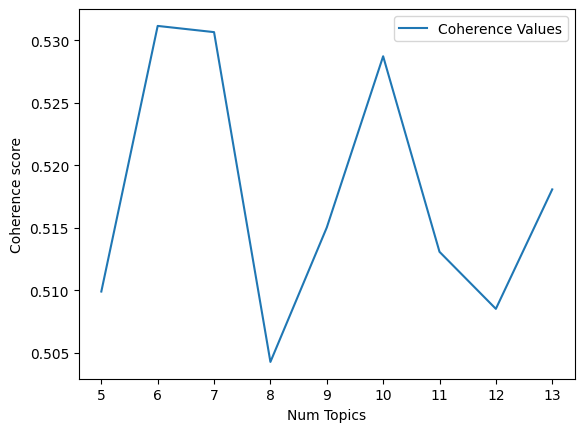

In [ ]:
limit = 14; start = 5; step = 1
x = range(start, limit, step)
plt.plot(x, cvs)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(["Coherence Values"], loc="best")
plt.show()

In [ ]:
optimal_model = models[2]

print_topics(optimal_model, num_words=13)

Topic 1: love, democrat, liberal, hey, cop, cow, thanks, get, dumb, empathy, threat, freedom, memory
Topic 2: people, say, abortion, make, would, see, one, go, think, even, know, link, want
Topic 3: right, baby, unborn, law, state, country, would, use, live, life, care, fuck, agree
Topic 4: life, human, begin, conception, abortion, cell, point, alive, say, believe, argument, end, form
Topic 5: baby, kill, child, woman, abortion, get, mother, make, would, want, pregnant, go, say
Topic 6: kill, child, life, right, murder, unborn, human, innocent, people, abortion, person, baby, say
Topic 7: murder, baby, kill, abortion, innocent, people, illegal, think, legal, stop, wrong, get, evil
